In [1]:
import json
from pathlib import Path

embeddings_path = Path("/kaggle/input/datasets/lianestrauch/bert-base-full/bert-base/chunks")
#/kaggle/input/datasets/lianestrauch/bert-base-full/bert-base/chunks



In [2]:
import pandas as pd

chunk_files = sorted((embeddings_path).glob("chunk_*.parquet"))


bert_embeddings = pd.read_parquet(
        chunk_files,
        columns=["id", "layer_last"],
    )

In [3]:
import gc
gc.collect()

0

Working at the sorted 100-dist graph
  Saved: k_distance_exports/k_distance_100.csv
Working at the sorted 500-dist graph
  Saved: k_distance_exports/k_distance_500.csv
Working at the sorted 1000-dist graph
  Saved: k_distance_exports/k_distance_1000.csv

Saved graph: k_distance_exports/sorted_k_distance_graphs.png


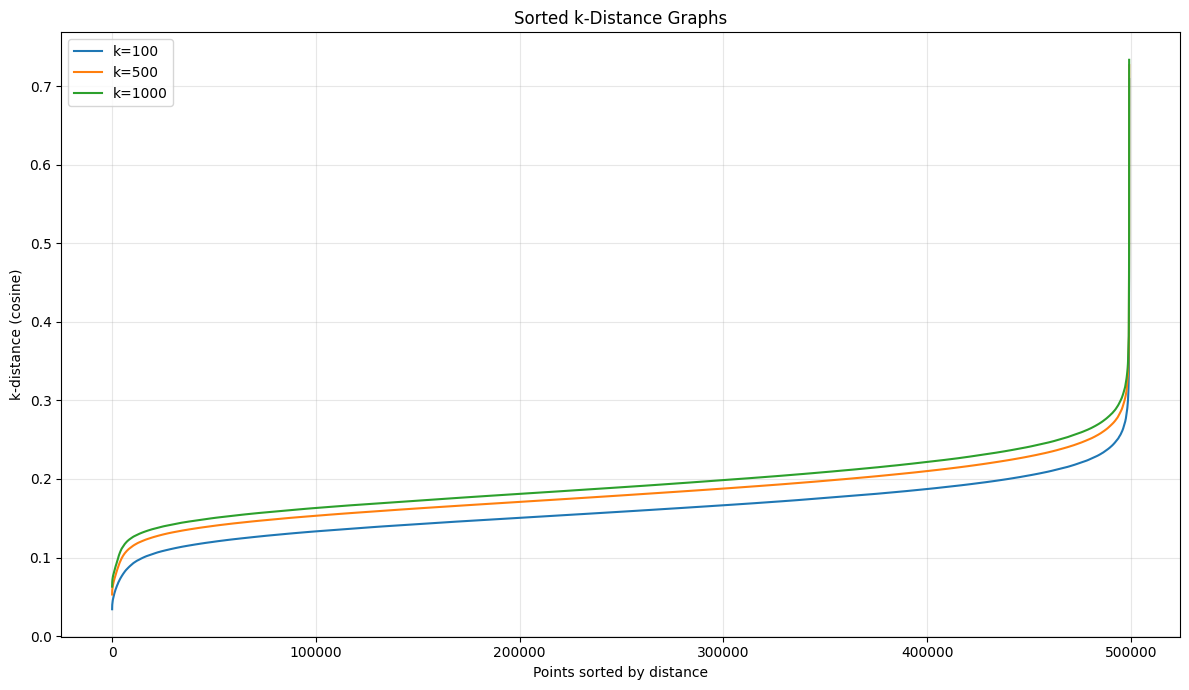

In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors

# -------------------------------------------------------
# Configuration
# -------------------------------------------------------

X = np.vstack(bert_embeddings["layer_last"].values)

k_values = [100, 500, 1000] #[50, 100, 500, 768, 1000, 1536]

output_dir = "k_distance_exports"
os.makedirs(output_dir, exist_ok=True)

# -------------------------------------------------------
# Calculate and export k-distance graphs
# -------------------------------------------------------

plt.figure(figsize=(12, 7))

for k in k_values:

    print(f"Working at the sorted {k}-dist graph")

    neighbors = NearestNeighbors(
        n_neighbors=k,
        metric="cosine"
    )

    neighbors.fit(X)

    distances, _ = neighbors.kneighbors(X)

    # Distance to kth nearest neighbor
    k_distances = distances[:, k - 1]

    # ---------------------------------------------------
    # Sort distances AND IDs together
    # ---------------------------------------------------

    sorted_indices = np.argsort(k_distances)

    sorted_distances = k_distances[sorted_indices]
    sorted_ids = bert_embeddings["id"].values[sorted_indices]

    # Rank after sorting
    ranks = np.arange(len(sorted_distances))

    # ---------------------------------------------------
    # Create export DataFrame
    # ---------------------------------------------------

    k_distance_df = pd.DataFrame({
        "rank": ranks,
        "id": sorted_ids,
        "k_distance": sorted_distances
    })

    # ---------------------------------------------------
    # Export CSV
    # ---------------------------------------------------

    csv_path = os.path.join(
        output_dir,
        f"k_distance_{k}.csv"
    )

    k_distance_df.to_csv(
        csv_path,
        index=False
    )

    print(f"  Saved: {csv_path}")

    # ---------------------------------------------------
    # Add to combined plot
    # ---------------------------------------------------

    plt.plot(
        sorted_distances,
        label=f"k={k}"
    )

# -------------------------------------------------------
# Format final graph
# -------------------------------------------------------

plt.xlabel("Points sorted by distance")
plt.ylabel("k-distance (cosine)")
plt.title("Sorted k-Distance Graphs")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()

# -------------------------------------------------------
# Export final graph
# -------------------------------------------------------

plot_path = os.path.join(
    output_dir,
    "sorted_k_distance_graphs.png"
)

plt.savefig(
    plot_path,
    dpi=300,
    bbox_inches="tight"
)

print(f"\nSaved graph: {plot_path}")

plt.show()